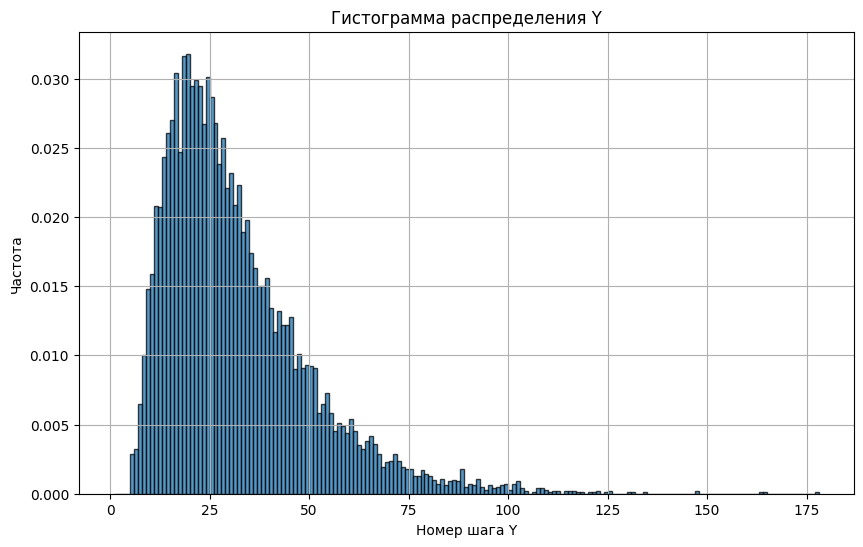

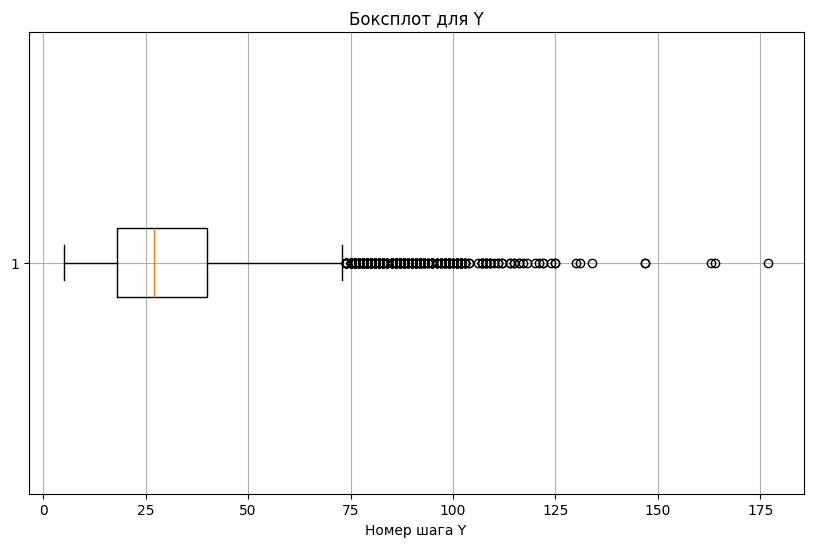

Математическое ожидание: 31.14
Медиана: 27.0
Дисперсия: 329.40
Асимметрия: 1.53
Эксцесс: 3.70


In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def simulate_experiment():
    # Определяем множество главных диагоналей шестиугольника (пары противоположных вершин)
    main_diags = {frozenset({0, 3}), frozenset({1, 4}), frozenset({2, 5})}

    # Множество для отслеживания пройденных главных диагоналей
    visited = set()

    # Начальная позиция частицы - вершина 0
    current = 0

    # Счетчик шагов
    step = 0

    while True:
        step += 1

        # Случайный выбор следующей вершины (не равной текущей)
        next_vertex = current
        while next_vertex == current:
            next_vertex = random.randint(0, 5)

        # Проверяем, является ли переход главной диагональю
        edge = frozenset({current, next_vertex})
        if edge in main_diags:
            visited.add(edge)

        # Если все 3 главные диагонали пройдены - завершаем эксперимент
        if len(visited) == 3:
            return step

        # Обновляем текущую позицию частицы
        current = next_vertex

# Генерация выборки
sample_size = 10000
samples = [simulate_experiment() for _ in range(sample_size)]

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=range(1, max(samples) + 2), density=True, alpha=0.75, edgecolor='black')
plt.title('Гистограмма распределения Y')
plt.xlabel('Номер шага Y')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

# Построение боксплота
plt.figure(figsize=(10, 6))
plt.boxplot(samples, vert=False)
plt.title('Боксплот для Y')
plt.xlabel('Номер шага Y')
plt.grid(True)
plt.show()

# Расчет статистик
mean = np.mean(samples)
median = np.median(samples)
variance = np.var(samples)
skewness = stats.skew(samples)
kurtosis = stats.kurtosis(samples)

print(f"Математическое ожидание: {mean:.2f}")
print(f"Медиана: {median}")
print(f"Дисперсия: {variance:.2f}")
print(f"Асимметрия: {skewness:.2f}")
print(f"Эксцесс: {kurtosis:.2f}")